# Upgrade Modelo 2: Clasificación de Riesgo de Salud (Avanzado)
Este notebook realiza el proceso completo de entrenamiento, evaluación y selección del mejor modelo para clasificar el riesgo de salud de los pacientes de ALDIMI.
Evaluaremos **Random Forest** vs **XGBoost**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [17]:
df = pd.read_csv('../datos/datos_modelo2/cancer_patient_data_sets_noisy.csv')
display(df.head())
print(df.info())

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,25,1,7,7,7,8,5,8,8,6,...,4,1,3,1,4,5,6,8,6,High
1,29,2,4,1,4,3,2,2,4,3,...,3,1,2,4,2,2,4,4,3,Low
2,27,1,3,1,4,3,2,3,4,3,...,4,2,2,4,1,2,4,4,3,Low
3,28,2,1,6,7,5,3,2,6,2,...,3,3,7,7,4,8,7,7,5,Medium
4,57,1,2,4,4,2,1,1,2,4,...,2,1,3,3,1,3,2,2,2,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       3000 non-null   int64 
 1   Gender                    3000 non-null   int64 
 2   Air Pollution             3000 non-null   int64 
 3   Alcohol use               3000 non-null   int64 
 4   Dust Allergy              3000 non-null   int64 
 5   OccuPational Hazards      3000 non-null   int64 
 6   Genetic Risk              3000 non-null   int64 
 7   chronic Lung Disease      3000 non-null   int64 
 8   Balanced Diet             3000 non-null   int64 
 9   Obesity                   3000 non-null   int64 
 10  Smoking                   3000 non-null   int64 
 11  Passive Smoker            3000 non-null   int64 
 12  Chest Pain                3000 non-null   int64 
 13  Coughing of Blood         3000 non-null   int64 
 14  Fatigue                 

## 2. Preprocesamiento de Datos
El dataset contiene valores categóricos y numéricos. La variable objetivo es `Level` (Low, Medium, High).

In [18]:
# Eliminar columnas innecesarias como Patient Id e index
if 'Patient Id' in df.columns:
    df.drop(['Patient Id'], axis=1, inplace=True)
if 'index' in df.columns:
    df.drop(['index'], axis=1, inplace=True)

X = df.drop('Level', axis=1)
y = df['Level']

# Low: 0, Medium: 1, High: 2 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Clases mapeadas:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Clases mapeadas: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 3. División de Datos (Train 70% / Val 15% / Test 15%)

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Total de muestras: {len(X)}")
print(f"Set de Entrenamiento: {len(X_train)} ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Set de Validación: {len(X_val)} ({(len(X_val)/len(X))*100:.1f}%)")
print(f"Set de Prueba: {len(X_test)} ({(len(X_test)/len(X))*100:.1f}%)")

Total de muestras: 3000
Set de Entrenamiento: 2100 (70.0%)
Set de Validación: 450 (15.0%)
Set de Prueba: 450 (15.0%)


## 4. Entrenamiento y Evaluación de Modelos Base en Validación
Entrenaremos Random Forest y XGBoost con hiperparámetros por defecto para tener una línea base.

In [20]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    print(f"--- Resultados para {model_name} (Validación) ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_val, y_pred, average='weighted'):.4f}\n")
    return y_pred

In [21]:
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_base.fit(X_train, y_train)
y_pred_rf = evaluate_model(rf_base, X_val, y_val, "Random Forest Base")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_base.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = evaluate_model(xgb_base, X_val, y_val, "XGBoost Base")

--- Resultados para Random Forest Base (Validación) ---
Accuracy:  0.9800
Precision: 0.9802
Recall:    0.9800
F1-Score:  0.9800

--- Resultados para XGBoost Base (Validación) ---
Accuracy:  0.9778
Precision: 0.9780
Recall:    0.9778
F1-Score:  0.9778



## 5. Ajuste de Hiperparámetros (GridSearchCV)
Buscamos la mejor combinación de parámetros para cada modelo.

In [23]:
# Hyperparameter Tuning: Random Forest
param_grid_rf = {
    'n_estimators': [10, 20, 25, 50, 100],
    'max_depth': [None, 2, 5, 7, 10, 15, 20],
    'min_samples_split': [2,3, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), 
                       param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Mejores parámetros Random Forest:", grid_rf.best_params_)
print(f"Mejor F1-Score (CV interno): {grid_rf.best_score_:.4f}")

Mejores parámetros Random Forest: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 10}
Mejor F1-Score (CV interno): 0.9714


Se llegó a determinar que la mejor combinación de hiperparámetros es {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 10}

In [29]:
# Hyperparameter Tuning: XGBoost
param_grid_xgb = {
    'n_estimators': [55, 56,57,58],
    'max_depth': [3,4,5, 6],
    'learning_rate': [0.25, 0.26,0.27,0.28,0.29,0.3]
}


grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), 
                        param_grid_xgb, cv=5, scoring='f1_weighted', n_jobs=-1)


grid_xgb.fit(X_train, y_train, **{'sample_weight': sample_weights})

best_xgb = grid_xgb.best_estimator_
print("Mejores parámetros XGBoost:", grid_xgb.best_params_)
print(f"Mejor F1-Score (CV interno): {grid_xgb.best_score_:.4f}")

Mejores parámetros XGBoost: {'learning_rate': 0.28, 'max_depth': 4, 'n_estimators': 55}
Mejor F1-Score (CV interno): 0.9706


Se llegó a determinar que la mejor combinación de hiperparámetros mediante distintas iteraciones añadiendo y eliminandolo del "param_grid_xgb" es:
- {'learning_rate': 0.28, 'max_depth': 4, 'n_estimators': 55}

## 6. Validación Cruzada (Robustez)
Verificamos qué tan robustos son los modelos optimizados usando todo el conjunto (Train + Val) antes del Test final.

In [30]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

sw_train_val = compute_sample_weight(class_weight='balanced', y=y_train_val)

cv_scores_rf = cross_val_score(best_rf, X_train_val, y_train_val, cv=5, scoring='f1_weighted')
print(f"Random Forest CV F1-Score: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

cv_scores_xgb = cross_val_score(best_xgb, X_train_val, y_train_val, cv=5, scoring='f1_weighted')
print(f"XGBoost CV F1-Score: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")

Random Forest CV F1-Score: 0.9722 (+/- 0.0129)
XGBoost CV F1-Score: 0.9698 (+/- 0.0146)


## 7. Prueba Final (Test Set)
Evaluamos al modelo ganador con los datos nunca antes vistos (Test 15%). Aquí seleccionaremos al mejor de los dos basados en el rendimiento de validación/CV.

In [31]:
# Determinamos cuál fue el mejor
if grid_rf.best_score_ > grid_xgb.best_score_:
    print("Seleccionando: Random Forest")
    final_model = best_rf
else:
    print("Seleccionando: XGBoost")
    final_model = best_xgb

# Evaluar en Test
y_pred_test = final_model.predict(X_test)
print("\n--- Resultados Finales en el Set de PRUEBA ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test, average='weighted'):.4f}\n")

print("Reporte de Clasificación Final:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))

Seleccionando: Random Forest

--- Resultados Finales en el Set de PRUEBA ---
Accuracy:  0.9667
Precision: 0.9668
Recall:    0.9667
F1-Score:  0.9667

Reporte de Clasificación Final:
              precision    recall  f1-score   support

        High       0.96      0.98      0.97       165
         Low       0.97      0.96      0.96       138
      Medium       0.97      0.97      0.97       147

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



## 8. Exportación del Modelo
Guardamos el modelo para que el Pipeline Principal lo pueda consumir.

In [32]:
import os
if not os.path.exists('../modelos'):
    os.makedirs('../modelos')

model_path = '../modelos/modelo_riesgo_pacientes_avanzado.joblib'
joblib.dump({'model': final_model, 'label_encoder': label_encoder}, model_path)
print(f"Modelo final exportado a {model_path}")

Modelo final exportado a ../modelos/modelo_riesgo_pacientes_avanzado.joblib


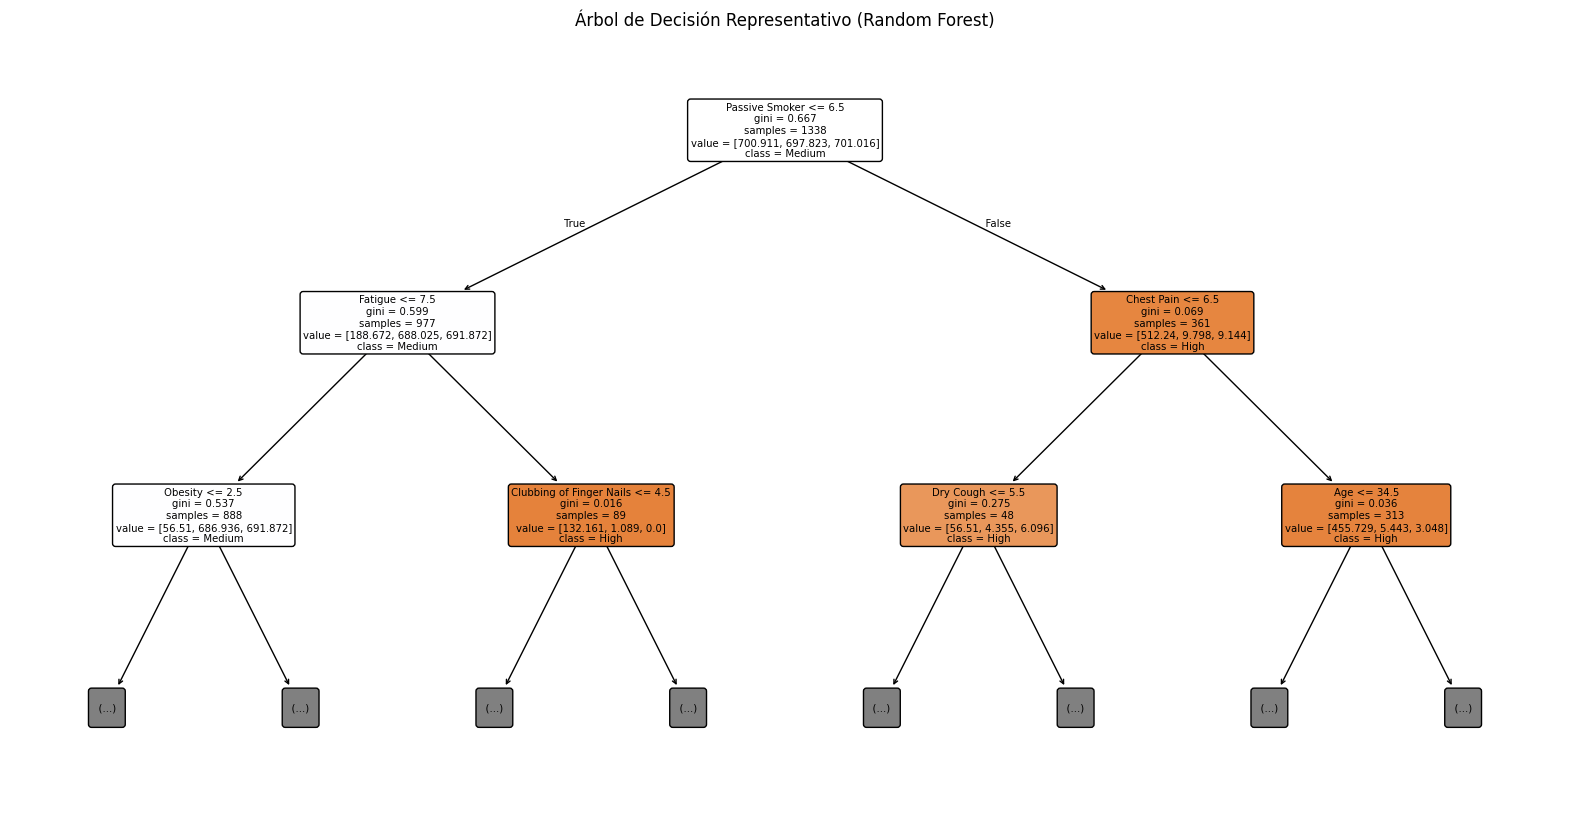

In [37]:
from sklearn.tree import plot_tree
arbol_representativo = final_model.estimators_[8]

plt.figure(figsize=(20, 10))
plot_tree(
    arbol_representativo, 
    feature_names=X.columns, 
    class_names=label_encoder.classes_, 
    filled=True, 
    rounded=True,
    max_depth=2 
)
plt.title('Árbol de Decisión Representativo (Random Forest)')
plt.show()
